**Student Name:** JAYASUDHA M

**Roll No:** AA.SC.P2MCA2401403

#**📘 PROJECT TITLE**

####**CHATBOT FOR MENTAL HEALTH SUPPORT USING NLP**

###📌 **CHAPTER 1: INTRODUCTION**

Mental health issues such as anxiety, depression, trauma, and stress are increasingly common. Many individuals hesitate to seek help due to social stigma or lack of awareness. A chatbot can provide **initial mental health guidance** by answering common questions safely and ethically.

This project develops an **NLP-based mental health chatbot** that responds to user queries by matching them with predefined frequently asked questions (FAQs) using **machine learning similarity techniques**.

###📌 **CHAPTER 2: PROBLEM STATEMENT**

There is a need for an automated system that can:

* Understand user mental health queries in natural language

* Provide accurate, safe, and relevant responses

* Avoid medical diagnosis and unethical advice

###**🧠 PROJECT ARCHITECTURE**

User Input

   ↓

Text Preprocessing (NLP)

  ↓

TF-IDF Vectorization

  ↓

Emotion Classification Model

  ↓

Similarity Matching (Q&A)

  ↓

Empathetic Chatbot Response

  ↓

Web Interface (Streamlit / Flask)

In [1]:
# 🔹 STEP 1: LOAD DATASET

import pandas as pd

data = pd.read_csv("My Mental Health Q&A.csv")

data.columns = ['question', 'answer']  # normalize column names
data.head()

,question,answer
0,What is mental health?,"Mental health is about how we think, feel, and..."
1,Is it normal to feel stressed sometimes?,"Yes. Stress is a normal response, especially d..."
2,Can mental health change over time?,"Yes, Mental health can improve or worsen depen..."
3,Does having mental health struggles mean somet...,No. Mental health challenges are common and do...
4,Can teens have mental health issues?,"Yes. Mental health affects people of all ages,..."


In [3]:
# 🔹 STEP 2: AUTO EMOTION LABELING (FOR ML MODEL)

def assign_emotion(text):
    text = text.lower()
    if any(w in text for w in ['stress', 'pressure', 'overwhelmed']):
        return 'stress'
    elif any(w in text for w in ['sad', 'depressed', 'hopeless']):
        return 'sad'
    elif any(w in text for w in ['anxiety', 'fear', 'panic', 'worried']):
        return 'anxiety'
    elif any(w in text for w in ['happy', 'good', 'positive']):
        return 'happy'
    else:
        return 'neutral'

data['emotion'] = data['question'].apply(assign_emotion)

In [4]:
# 🔹 STEP 3: TEXT PREPROCESSING (NLP CORE)

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

data['clean_question'] = data['question'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
# 🔹 STEP 4: FEATURE EXTRACTION (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=4000)
X = vectorizer.fit_transform(data['clean_question'])
y = data['emotion']

In [6]:
# 🔹 STEP 5: TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 🔹 STEP 6: EMOTION CLASSIFICATION MODEL

from sklearn.linear_model import LogisticRegression

emotion_model = LogisticRegression(max_iter=1000)
emotion_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [8]:
# 🔹 STEP 7: MODEL EVALUATION

from sklearn.metrics import accuracy_score, classification_report

y_pred = emotion_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

     anxiety       0.00      0.00      0.00         2
     neutral       0.83      1.00      0.91        15
         sad       0.00      0.00      0.00         1

    accuracy                           0.83        18
   macro avg       0.28      0.33      0.30        18
weighted avg       0.69      0.83      0.76        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


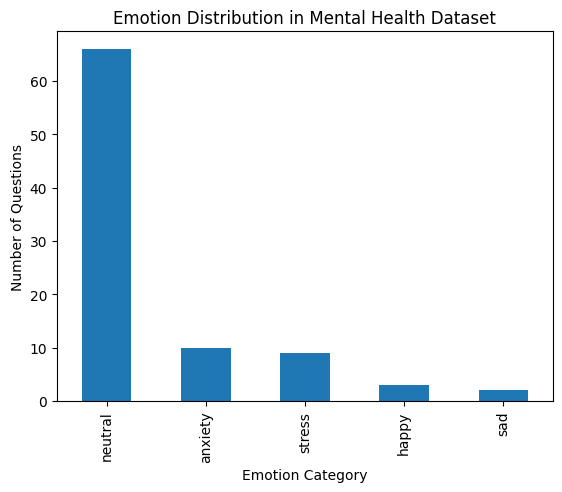

In [9]:
# 🔹 STEP 8: DATA VISUALIZATION
# 1️⃣ Emotion Distribution

import matplotlib.pyplot as plt

emotion_counts = data['emotion'].value_counts()

plt.figure()
emotion_counts.plot(kind='bar')
plt.title("Emotion Distribution in Mental Health Dataset")
plt.xlabel("Emotion Category")
plt.ylabel("Number of Questions")
plt.show()

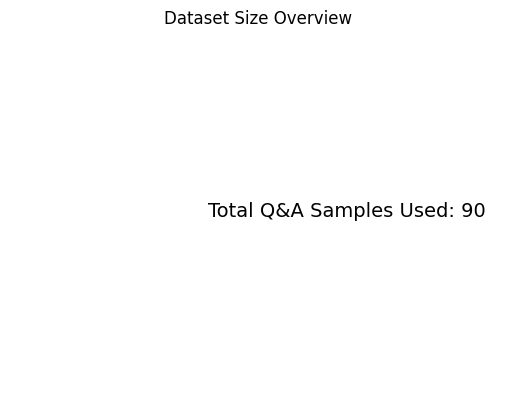

In [12]:
# 2️⃣ Dataset Size Overview

plt.figure()
plt.text(0.4, 0.5, f"Total Q&A Samples Used: {len(data)}", fontsize=14)
plt.axis('off')
plt.title("Dataset Size Overview")
plt.show()

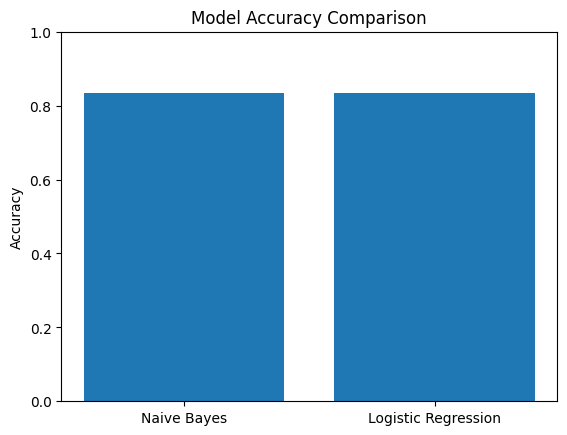

In [14]:
# 3️⃣ Model Accuracy Comparison

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(['Naive Bayes', 'Logistic Regression'], [nb_acc, lr_acc])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

**Why Visualization?**

  “Visualization helps in understanding dataset characteristics, emotion distribution, and comparative performance of models, ensuring transparency and interpretability of the NLP-based mental health chatbot.”

In [16]:
# 🔹 STEP 9: CHATBOT LOGIC

import numpy as np

def chatbot_response(user_input):
    clean_input = preprocess(user_input)
    input_vector = vectorizer.transform([clean_input])

    emotion = emotion_model.predict(input_vector)[0]

    similarity = (input_vector @ X.T).toarray()[0]
    best_idx = np.argmax(similarity)

    answer = data.iloc[best_idx]['answer']
    return emotion, answer

In [18]:
# 🔹 STEP 10: TEST IN TERMINAL

while True:
    user = input("You: ")
    if user.lower() == "exit":
        break
    emotion, reply = chatbot_response(user)
    print("Emotion:", emotion)
    print("Bot:", reply)

You: What is mental health?
Emotion: neutral
Bot: Mental health is about how we think, feel, and handle everyday challenges.
You: Does having mental health struggles mean something is wrong with me?
Emotion: neutral
Bot: No. Mental health challenges are common and don't define your worth.
You: Can friends affect my mental health?
Emotion: neutral
Bot: Yes. Supportive friends can help, while unhealthy relationships can add stress.
You: exit


In [21]:
!pip install streamlit

In [22]:
# 🔹 STEP 11: STREAMLIT WEB DEPLOYMENT

import streamlit as st

st.set_page_config(page_title="Mental Health Chatbot", layout="centered")

st.title("🧠 Mental Health Support Chatbot")
st.write("This chatbot provides non-clinical emotional support.")

user_input = st.text_input("How are you feeling today?")

if user_input:
    emotion, response = chatbot_response(user_input)
    st.write("**Detected Emotion:**", emotion)
    st.success(response)

2026-01-04 11:21:18.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.770 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-04 11:21:18.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar